In [2]:
import pandas as pd

df = pd.read_csv(r"F:\AI-ML-BootCamp\NETSOL WORK\Week_5\Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df.fillna(method='ffill', inplace=True)

C:\Users\Mani\AppData\Local\Temp\ipykernel_21328\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [8]:
df['delivery_time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [9]:
df['is_profit'] = (df['Profit'] > 0).astype(int)

In [10]:
orders_per_day = df.groupby('Order Date').size()

In [12]:
# Bernoulli distribution for profit
import pandas as pd

# Bernoulli column create
df['is_profit'] = (df['Profit'] > 0).astype(int)

df[['Profit', 'is_profit']].head()

,Profit,is_profit
0,41.9136,1
1,219.5820,1
2,6.8714,1
3,-383.0310,0
4,2.5164,1


In [13]:
df['is_profit'].value_counts()

is_profit
1    8058
0    1936
Name: count, dtype: int64

In [14]:
p = df['is_profit'].mean()
print(p)

0.8062837702621573


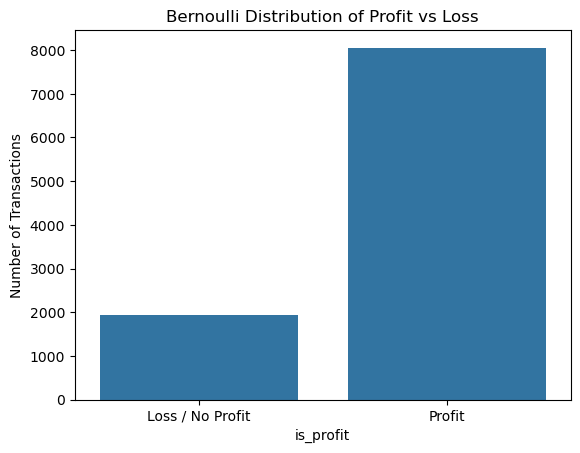

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_profit', data=df)
plt.xticks([0, 1], ['Loss / No Profit', 'Profit'])
plt.title('Bernoulli Distribution of Profit vs Loss')
plt.ylabel('Number of Transactions')
plt.show()

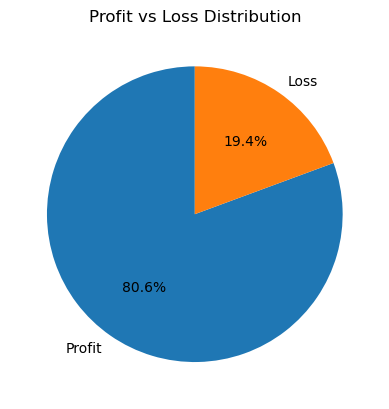

In [17]:
profit_counts = df['is_profit'].value_counts()
plt.pie(profit_counts, labels=['Profit','Loss'], autopct='%1.1f%%', startangle=90)
plt.title('Profit vs Loss Distribution')
plt.show()

Binomial Distribution

In [18]:
# Group by customer and count profitable orders
customer_orders = df.groupby('Customer ID')['is_profit'].sum().reset_index()
customer_orders.rename(columns={'is_profit':'profitable_orders'}, inplace=True)

# Number of orders per customer
customer_orders['total_orders'] = df.groupby('Customer ID').size().values

customer_orders.head()

,Customer ID,profitable_orders,total_orders
0,AA-10315,10,11
1,AA-10375,15,15
2,AA-10480,12,12
3,AA-10645,15,18
4,AB-10015,5,6


In [19]:
p = df['is_profit'].mean()
print(f"Probability of a single profitable order: {p}")

Probability of a single profitable order: 0.8062837702621573


(array([0.00126103, 0.01513241, 0.02900378, 0.03909206, 0.04791929,
        0.07061791, 0.07313997, 0.0630517 , 0.06809584, 0.08701135,
        0.07313997, 0.07187894, 0.06557377, 0.06809584, 0.04791929,
        0.04035309, 0.02900378, 0.02017654, 0.02143758, 0.01134931,
        0.01639344, 0.00504414, 0.01008827, 0.00252207, 0.00252207,
        0.00126103, 0.0037831 , 0.00630517, 0.00126103, 0.00126103,
        0.00252207, 0.0037831 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.]),
 <BarContainer object of 38 artists>)

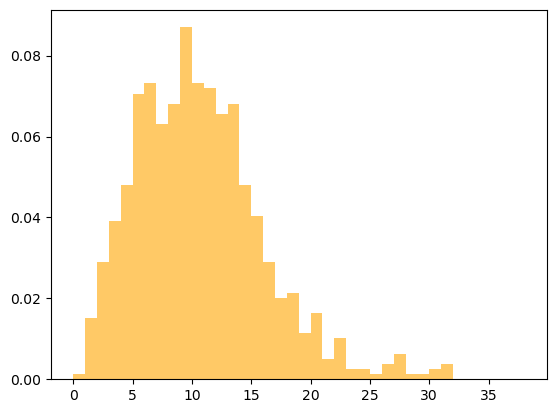

In [21]:
from scipy.stats import binom
import numpy as np
# Number of experiments (simulate for each customer)
n_experiments = customer_orders['total_orders'].max()  # max orders per customer

# Simulated Binomial values
x = np.arange(0, n_experiments+1)
pmf = binom.pmf(x, n=n_experiments, p=p)

# Histogram of actual profitable orders (normalized for density)
plt.hist(customer_orders['profitable_orders'], bins=range(0, n_experiments+2), density=True,
         alpha=0.6, color='orange', label='Customer Data')

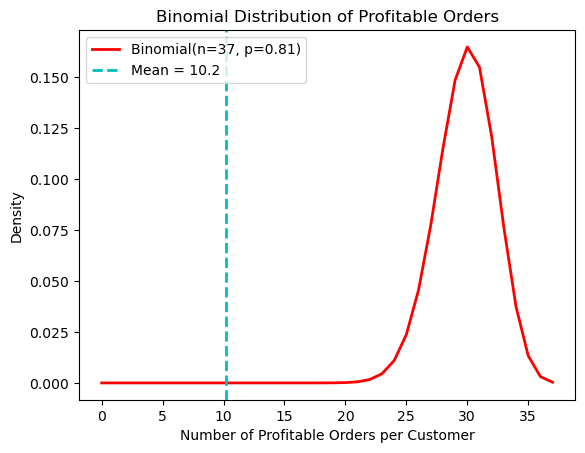

In [22]:
plt.plot(x, pmf, 'r-', lw=2, label=f'Binomial(n={n_experiments}, p={p:.2f})')
plt.axvline(customer_orders['profitable_orders'].mean(), color='c', linestyle='--', lw=2, label=f'Mean = {customer_orders["profitable_orders"].mean():.1f}')

plt.xlabel('Number of Profitable Orders per Customer')
plt.ylabel('Density')
plt.title('Binomial Distribution of Profitable Orders')
plt.legend()
plt.show()

In [24]:
import pandas as pd
# Order Date convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Orders per day (count of rows per date)
orders_per_day = df.groupby('Order Date').size().reset_index(name='num_orders')
orders_per_day.head()

,Order Date,num_orders
0,2014-01-03,1
1,2014-01-04,3
2,2014-01-05,1
3,2014-01-06,9
4,2014-01-07,2


In [25]:
lambda_poisson = orders_per_day['num_orders'].mean()
print(f"Average orders per day (lambda): {lambda_poisson:.2f}")

Average orders per day (lambda): 8.08


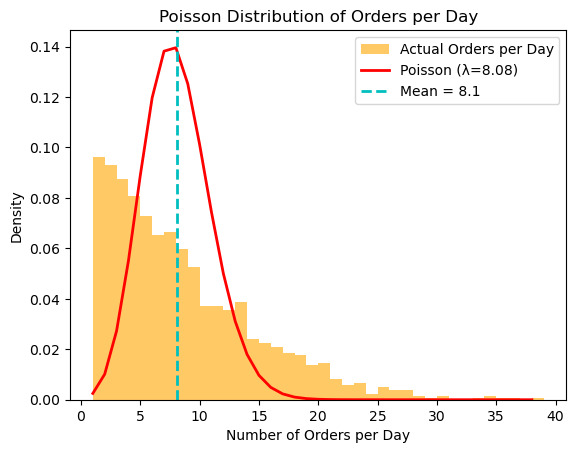

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# X values for PMF
x = np.arange(orders_per_day['num_orders'].min(), orders_per_day['num_orders'].max()+1)

# PMF values
pmf = poisson.pmf(x, mu=lambda_poisson)

# Plot histogram of actual data
plt.hist(orders_per_day['num_orders'], bins=range(orders_per_day['num_orders'].min(),
         orders_per_day['num_orders'].max()+2), density=True, alpha=0.6, color='orange', label='Actual Orders per Day')

# Overlay Poisson PMF
plt.plot(x, pmf, 'r-', lw=2, label=f'Poisson (λ={lambda_poisson:.2f})')

# Mean line
plt.axvline(lambda_poisson, color='c', linestyle='--', lw=2, label=f'Mean = {lambda_poisson:.1f}')

plt.xlabel('Number of Orders per Day')
plt.ylabel('Density')
plt.title('Poisson Distribution of Orders per Day')
plt.legend()
plt.show()